# PCRGlobWB

Let us look at the Speyside region again!
PCRGlobWB uses a clonemap, this means we will need to make one for the Speyside!
We will do that after the forcing generation.

Please note that when you do this yourself, think of a smart way to divide this notebook into several ones.

In [1]:
# This is only used to suppress some distracting output messages
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import subprocess
import matplotlib.pyplot as plt
from cartopy import crs
from cartopy import feature as cfeature
from rich import print
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime
from ipywidgets import IntProgress
from IPython.display import display
import fiona
import shapely.geometry
from pyproj import Geod
import logging

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets

logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

In [2]:
# Region selection using Caravan
"""Avon at Delnashaugh, in Scotland"""
caravan_id = "camelsgb_8004"

# Station BOAT O BRIG, river Spey
station_latitude = 	57.55104
station_longitude = -3.14039

# Time periods for experiment, note they are hydrological years
experiment_start_date = "2005-08-01T00:00:00Z"
experiment_end_date = "2006-08-31T00:00:00Z"

In [3]:
forcing_path_caravan = Path.home() / "forcing" / caravan_id / "caravan"
forcing_path_caravan.mkdir(exist_ok=True, parents=True)

forcing_path_pcrglobwb = Path.home() / "forcing" / caravan_id / "pcrglobwb"
forcing_path_pcrglobwb.mkdir(exist_ok=True)

prepared_pcrglobwb_forcing = forcing_path_pcrglobwb / "work/diagnostic/script"

pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")

In [4]:
try:
    # Option two: load data that you or someone else generated previously
    caravan_forcing = ewatercycle.forcing.sources['CaravanForcing'].load(directory=forcing_path_caravan)
except:
    # Option one: generate forcing data
    caravan_forcing = ewatercycle.forcing.sources['CaravanForcing'].generate(
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        directory=forcing_path_caravan,
        basin_id=caravan_id,
    )


Now we will generate the PCRGlobWB forcing.

In [5]:
# Set the extent of the forcing data sufficiently larger than the clonemap.
esmvaltool_padding = 0.5

region_Scotland = {
        "start_longitude": -9-esmvaltool_padding,
        "end_longitude": -1+esmvaltool_padding,
        "start_latitude": 50-esmvaltool_padding,
        "end_latitude": 61+esmvaltool_padding,
}


climate_start_date = experiment_start_date
years_of_climatology = 1
climate_end_date = f"{int(experiment_start_date[:4]) + years_of_climatology}{experiment_start_date[4:]}"

try:
    pcrglobwb_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
        directory=prepared_pcrglobwb_forcing,
    )
except:
     pcrglobwb_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
        dataset="ERA5",
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        start_time_climatology=experiment_start_date,
        end_time_climatology=climate_end_date,
        shape=caravan_forcing.shape,
        extract_region=region_Scotland,
        directory = forcing_path_pcrglobwb
    )

print(pcrglobwb_forcing)

PCRGlobWBForcing(
    start_time='2005-08-01T00:00:00Z',
    end_time='2006-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing/camelsgb_8004/pcrglobwb/work/diagnostic/script'),
    shape=PosixPath('/home/mmelotto/forcing/camelsgb_8004/caravan/camelsgb_8004.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2005-2006_camelsgb_8004.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_2005-2006_camelsgb_8004.nc'
)

In [6]:
print(pcrglobwb_forcing)

PCRGlobWBForcing(
    start_time='2005-08-01T00:00:00Z',
    end_time='2006-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing/camelsgb_8004/pcrglobwb/work/diagnostic/script'),
    shape=PosixPath('/home/mmelotto/forcing/camelsgb_8004/caravan/camelsgb_8004.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2005-2006_camelsgb_8004.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_2005-2006_camelsgb_8004.nc'
)

## Plot the forcing

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 1095, lat: 49, lon: 37, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2004-01-02 2004-01-03 ... 2006-12-31
  * lat        (lat) float32 196B 61.5 61.25 61.0 60.75 ... 50.0 49.75 49.5
  * lon        (lon) float32 148B -9.499 -9.249 -8.999 ... -0.999 -0.749 -0.499
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 8MB 279.4 279.4 279.4 ... 284.7 284.7
    time_bnds  (time, bnds) datetime64[ns] 18kB 2004-01-01T12:00:00 ... 2006-...
    lat_bnds   (lat, bnds) float32 392B 61.62 61.38 61.38 ... 49.62 49.62 49.38
    lon_bnds   (lon, bnds) float32 296B -9.625 -9.375 -9.375 ... -0.625 -0.375
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.

------------------------

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 1095, lat: 49, lon: 37, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2004-01-02 2004-01-03 ... 2006-12-31
  * lat        (lat) float32 196B 61.5 61.25 61.0 60.75 ... 50.0 49.75 49.5
  * lon        (lon) float32 148B -9.499 -9.249 -8.999 ... -0.999 -0.749 -0.499
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 8MB 0.002335 0.002427 ... 0.006291
    time_bnds  (time, bnds) datetime64[ns] 18kB 2004-01-01T12:00:00 ... 2006-...
    lat_bnds   (lat, bnds) float32 392B 61.62 61.38 61.38 ... 49.62 49.62 49.38
    lon_bnds   (lon, bnds) float32 296B -9.625 -9.375 -9.375 ... -0.625 -0.375
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.

------------------------

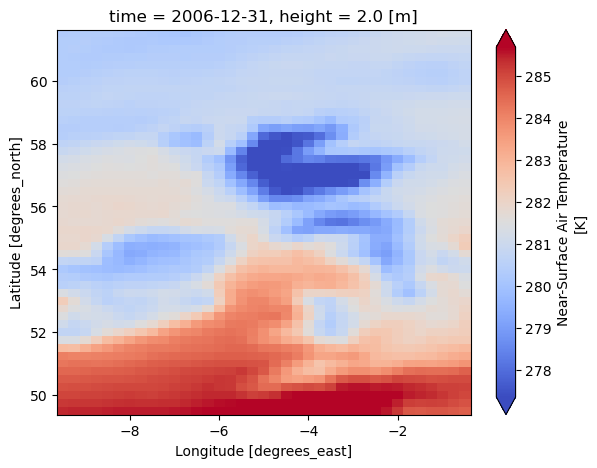

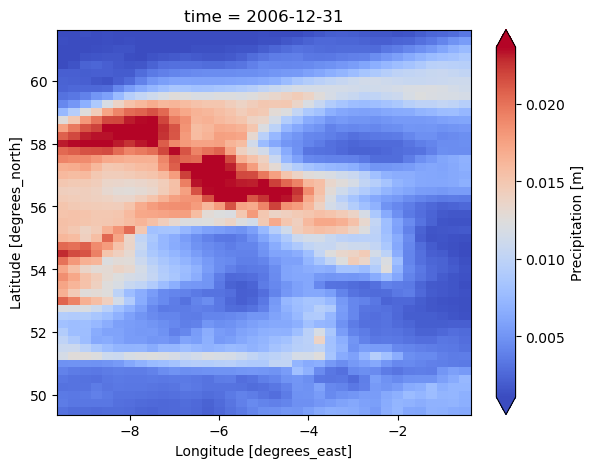

In [7]:
for file_name in [pcrglobwb_forcing.temperatureNC, pcrglobwb_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{pcrglobwb_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

## The clonemap

Be careful here with the forcing resolution.
If the model run throws an error where the array size does not add up to raster, play around with the forcing resolution.

In [8]:
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution."""
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        "an integer number of grid cells."
    )
    assert dlon % forcing_resolution == 0, f"Longitudes not compatible. {msg}"
    assert dlat % forcing_resolution == 0, f"Latitudes not compatible. {msg}"

    clonemap_dir = (
        "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"
    )
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    # outputclonemap = forcing_path_pcrglobwb / f"{catchment.lower()}_05min.map"  # copy to clonemap dir after ensuring it is correct
    outputclonemap =  f"{catchment.lower()}_05min.map"  # copy to clonemap dir after ensuring it is correct


    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap

In [9]:
# Catchment bounding boxes
clonemap_extents = {
    "Speyside": {"latitude": (57, 58), "longitude": (-4.5, -2.5)},
}

forcing_resolution = 0.5
for (catchment, extents) in clonemap_extents.items():
    latmin, latmax = extents["latitude"]
    lonmin, lonmax = extents["longitude"]
    print(
        create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment)
    )

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.


speyside_05min.map

## Parameter set

For the parameter set we require a .ini file.
This is a file you have to edit yourself!
Here we put it in the same directory as this notebook to make it easier to edit on the fly.

This .ini file is very tricky for version 1.0, we overwrite most of the global parameters, but you have to change the **cloneMap** and **landMask**.
Also note that everything is relative to the inputDir, which is: /data/shared/parameter-sets/pcrglobwb_global.
**This also means that you have to ask an administrator to put your cloneMap in the correct folder!!!**

In [10]:
# Print some values for the .ini file
print(f"cloneMap: {forcing_path_pcrglobwb / f"{catchment.lower()}_05min.map"}")

cloneMap: /home/mmelotto/forcing/camelsgb_8004/pcrglobwb/speyside_05min.map

startTime: 2005-08-01

endTime: 2006-08-31

In [11]:
# Parameter set
parameter_set = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    # direrctory=forcing_path_pcrglobwb,
    # config=forcing_path_pcrglobwb / f"speyside_05min.ini",
    config="./speyside_05min.ini",
    target_model="pcrglobwb",
    supported_model_versions={"setters"},
)

In [12]:
print(parameter_set)

ParameterSet(
    name='custom_parameter_set',
    directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
    config=PosixPath('speyside_05min.ini'),
    doi='N/A',
    target_model='pcrglobwb',
    supported_model_versions={'setters'},
    downloader=None
)

## PCRGlobWB Model

In [13]:
pcrglob = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set,
    forcing=pcrglobwb_forcing
)

print(pcrglob)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('speyside_05min.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'setters'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='2005-08-01T00:00:00Z',
        end_time='2006-08-31T00:00:00Z',
        directory=PosixPath('/home/mmelotto/forcing/camelsgb_8004/pcrglobwb/work/diagnostic/script'),
        shape=PosixPath('/home/mmelotto/forcing/camelsgb_8004/caravan/camelsgb_8004.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2005-2006_camelsgb_8004.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_2005-2006_camelsgb_8004.nc'
    )
)

In [14]:
print(pcrglob.parameters)

dict_items([('start_time', '2005-08-01T00:00:00Z'), ('end_time', '2005-08-01T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

In [15]:
cfg_file, cfg_dir = pcrglob.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=0
)

In [16]:
pcrglob_para = pcrglob.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
end_time = datetime.strptime(experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

Number of days to model: 395

In [17]:
# Initialize
pcrglob.initialize(cfg_file)

In [18]:
time = pd.date_range(pcrglob.start_time_as_isostr, pcrglob.end_time_as_isostr)
timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["PCRGlobWB: BOAT O BRIG"]
)

In [19]:
# Progress bar, since this can take a while
f = IntProgress(min=0, max=number_of_days)  # instantiate the bar
display(f)  # display the bar

while pcrglob.time < pcrglob.end_time:
    pcrglob.update()

    # Track discharge at station location
    discharge_at_station = pcrglob.get_value_at_coords(
        "discharge", lat=[station_latitude], lon=[station_longitude]
    )
    time = pcrglob.time_as_isostr
    timeseries.loc[time, "PCRGlobWB: BOAT O BRIG"] = discharge_at_station[0]

    # Update progress bar
    f.value += 1

print("Model run finished!")

IntProgress(value=0, max=395)

Model run finished!

## Interact with the model

**NOTE** we will need to finalize the model later!!

The model has a lot of variables, you can find them in the section about PCRGlobWB in getting started or

In [20]:
# List the variables
# list(pcrglob.output_var_names)

In [21]:
# Getting the discharge

da = pcrglob.get_value_as_xarray("discharge")
da.thin(5)  # only show every 5th value in each dim

<xarray.DataArray (longitude: 3, latitude: 5)> Size: 120B
array([[ 1.81443286, 12.58561325,  9.80098343, 21.97473335, 27.35209465],
       [ 0.32846063,  0.        ,  0.        , 65.77898407,  1.20256948],
       [ 1.44196761,  0.37811667,  0.        ,  0.        ,  0.        ]])
Coordinates:
  * latitude   (latitude) float64 40B -4.458 -4.042 -3.625 -3.208 -2.792
  * longitude  (longitude) float64 24B 57.04 57.46 57.88

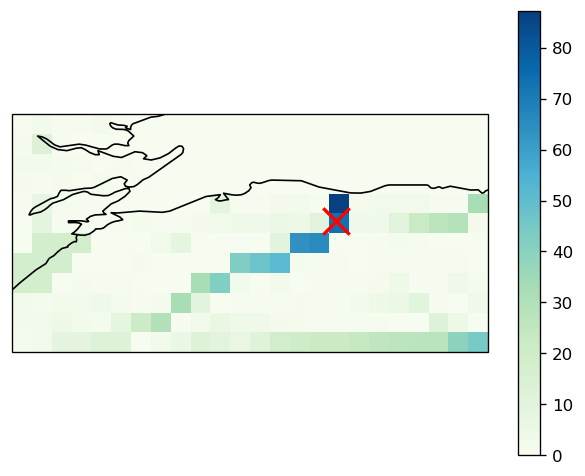

In [22]:
fig = plt.figure(dpi=120)
ax = fig.add_subplot(111, projection=crs.PlateCarree())
da.plot(ax=ax, cmap="GnBu")

# Overlay ocean and coastlines
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS, color="k")
ax.coastlines()

# Add a red cross marker at the location of the Leven River at Newby Bridge
ax.scatter(station_longitude, station_latitude, s=250, c="r", marker="x", lw=2)

Text(0, 0.5, 'Discharge $[m^3/s]$')

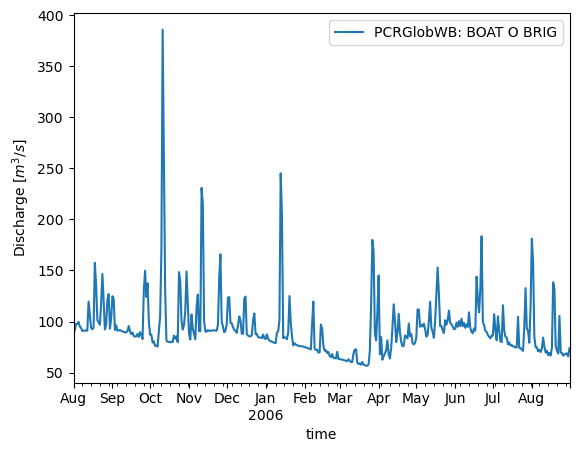

In [23]:
# Get the discharge data
timeseries.plot()
plt.ylabel("Discharge $[m^3/s]$")

## Finalize the model

In [24]:
pcrglob.finalize()